Import Libraries

In [48]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Load datasets

In [49]:
X_train = pd.read_csv('X_train_processed.csv')
X_test = pd.read_csv('X_test_processed.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

Binarize Risk Scores

In [ ]:
# Binarize risk scores: High Risk = 1 (score >= 60), else 0
def bin_risk_score_binary(score):
    return 1 if score >= 75 else 0

y_train_binned = y_train['risk_score'].apply(bin_risk_score_binary)
y_test_binned = y_test['risk_score'].apply(bin_risk_score_binary)



Fit Random Forest

In [51]:
# Fit Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train_binned)


RandomForestClassifier(class_weight='balanced', random_state=42)

Predict and Evaluate

In [52]:
# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
print("Accuracy Score:", accuracy_score(y_test_binned, y_pred))
print("\nClassification Report:\n", classification_report(y_test_binned, y_pred, zero_division=0))

Accuracy Score: 0.8809523809523809

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.97      0.90      0.94        41

    accuracy                           0.88        42
   macro avg       0.49      0.45      0.47        42
weighted avg       0.95      0.88      0.91        42



Confusion Matrix

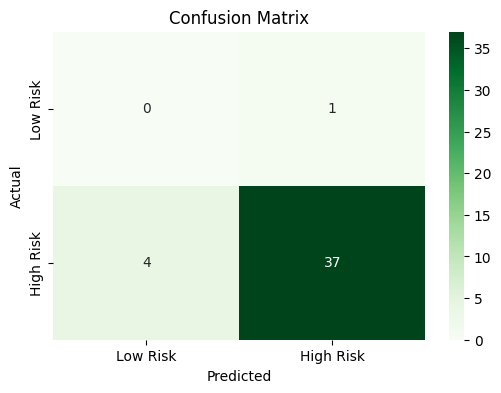

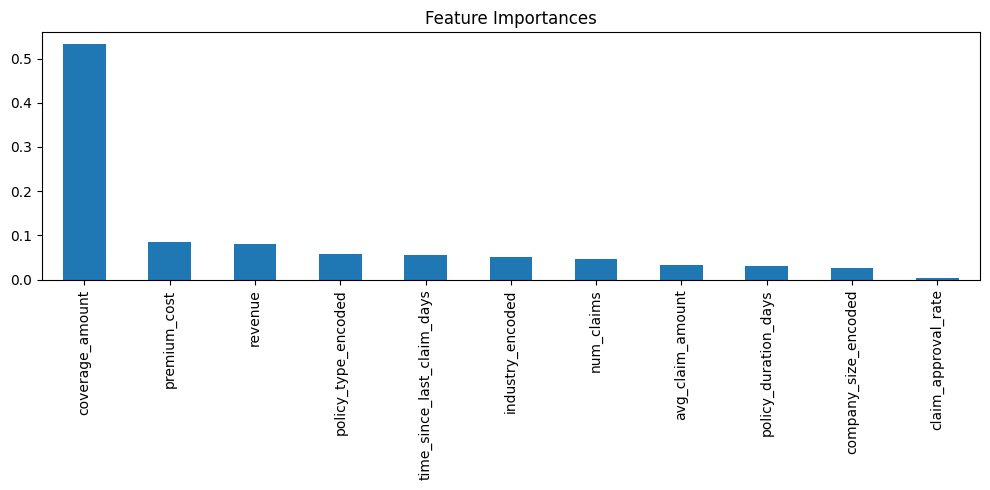

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test_binned, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Optional: Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), title='Feature Importances')
plt.tight_layout()
plt.show()

Add SHAP

In [54]:
# ---------------- SHAP EXPLAINABILITY ---------------- #
import shap

# SHAP expects raw model inputs — make sure this works on a sample row
explainer = shap.Explainer(rf_model.predict, X_train)

# Get SHAP values for test data
shap_values = explainer(X_test)

# Plot SHAP summary (Feature importance & direction)
shap.summary_plot(shap_values, X_test, show=False)

# Save as PNG to your assets folder (make sure this path matches your Dash app)
plt.savefig('assets/shap_summary.png', bbox_inches='tight')
plt.close()

print("SHAP summary plot saved to 'assets/shap_summary.png'")

C:\Users\misha\AppData\Local\Temp\ipykernel_11328\3579790601.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


SHAP summary plot saved to 'assets/shap_summary.png'
